In [57]:
import sys
sys.path.append("../utils/py")
import miniramses as ram

In [58]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import argparse
import miniramses as ram

plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 800
plt.rcParams.update({
    "font.size": 20,
    "legend.fontsize": 18,
})

prefix = 'grav'
path = '/home/jl4415/mini-ramses/'
nout = '4'

center = np.array([600,600,600])
log0=None

if prefix is None:
    prefix="hydro"
if path is None:
    path="./"
else:
    path=path+"/"

if prefix=="hydro":
    isort=0
if prefix=="peak":
    isort=1
if prefix=="grav":
    isort=0
if prefix=="rt":
    isort=0

print("Reading output number ",nout)

def amr_slice(c, cen, levels=None):
    """
    Select cells whose volume intersects the slice plane z = cen.
    Optionally filter by AMR level.
    """

    # plane intersects cell if |z - cen| < dx/2
    mask = np.abs(c.x[2] - cen) <= c.dx/2

    # optional level selection
    if levels is not None:
        mask = mask & np.isin(c.level, levels)

    x  = c.x[0][mask]
    y  = c.x[1][mask]
    dx = c.dx[mask]

    return x, y, dx, mask

# -----------------------------
# PLOT SINGLE OUTPUT
# -----------------------------

def plot(nout, cen=600, grid=False, levels=None):

    print("Reading output",nout)

    c = ram.rd_cell(nout,path=path,prefix=prefix,center=center)
    i = ram.rd_info(nout,path=path)

    print("Available levels:",np.unique(c.level))

    x,y,dx,mask = amr_slice(c,cen,levels)

    val = c.g[0][mask]

    ram.visu(x,y,dx,val,c.level,grid=grid)


# -----------------------------
# COMPARE TWO OUTPUTS
# -----------------------------

def compare(nout, nout_base, cen=600, grid=False, levels=None):

    print("Reading output",nout,"and base",nout_base)

    c = ram.rd_cell(str(nout),path=path,prefix=prefix,center=center)
    c_base = ram.rd_cell(str(nout_base),path=path,prefix=prefix,center=center)

    x,y,dx,mask = amr_slice(c,cen,levels)

    diff = c.g[0] - c_base.g[0]

    val = diff[mask]

    ram.visu(x,y,dx,val,c.level,grid=grid)
    print("mean relative error:",
        np.mean(val / c_base.g[0][mask])
    )

    print("median relative error:",
        np.median(val / c_base.g[0][mask])
    )

Reading output number  4


In [59]:
#nout =  '3'  # fmm (7,8) ! pre-direct-multipole expansion
#nout =  '4'  # multgrid  (7,8)
#nout =  '5'  # multigrid (8,8)
#nout =  '6'  # fmm (8,8)
#nout =  '23'  # fmm (7,8,9) ! pre-direct-multipole expansion
#nout =  '24'  # multgrid  (7,8,9)

Reading output 2
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
Available levels: [6 7 8]
image range: -130217.2109375 -13209.3369140625
Reading output 24 and base 2
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
image range: -3277.7578125 -12.310546875
mean relative error: 0.0037541324420461183
median relative error: 0.0035049360948855787


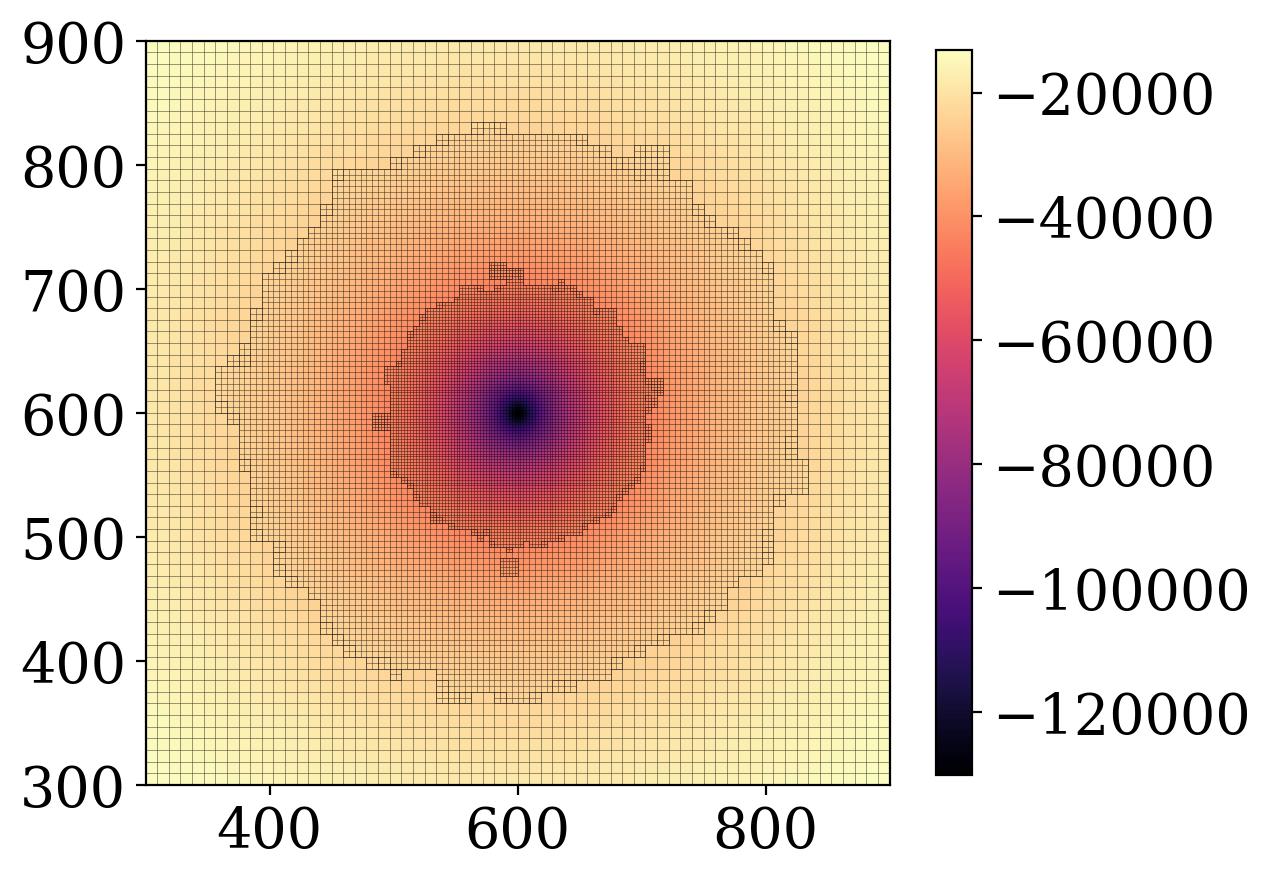

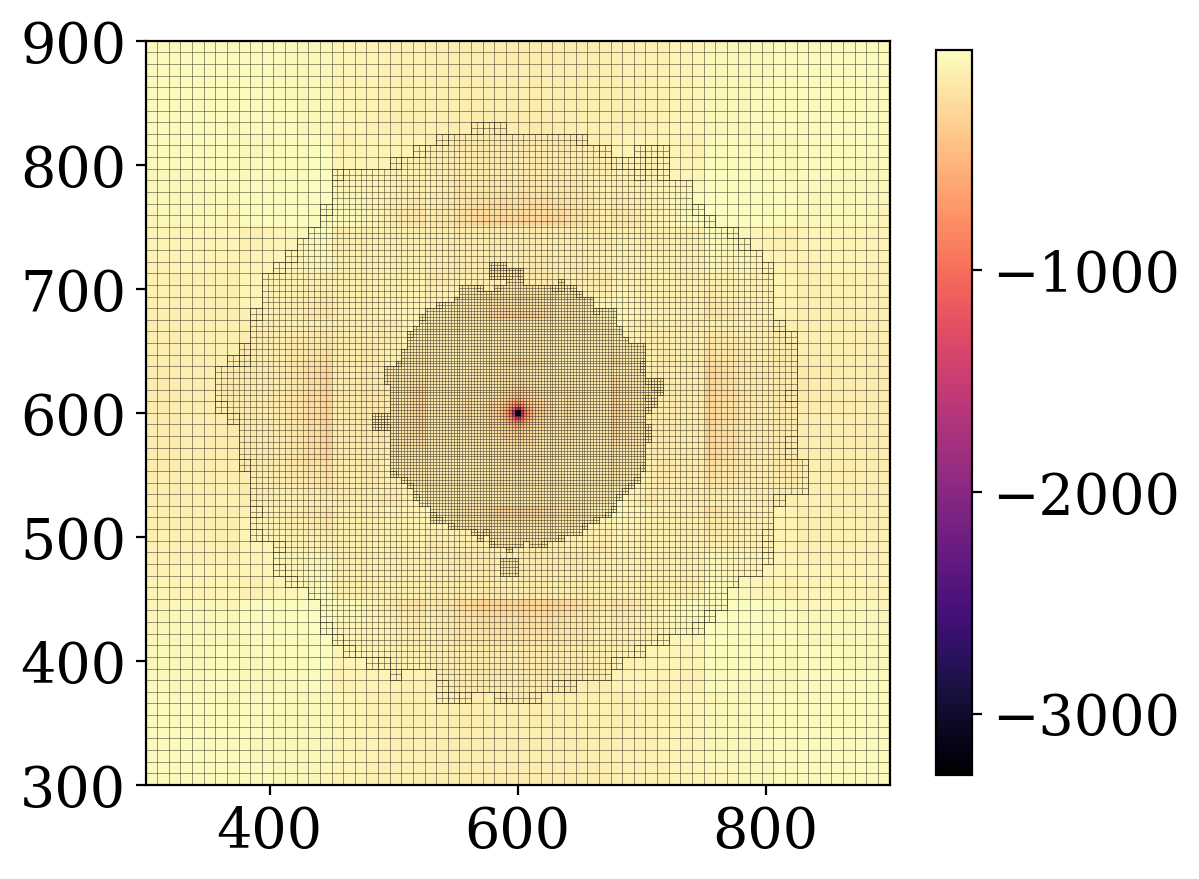

In [61]:
plot(2, 600, grid=True)
compare(24, 2, 600, grid=True)

#mk_image // project

Reading output 24 and base 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
image range: -3277.7578125 39.625
median relative error: 0.0037571818978789397


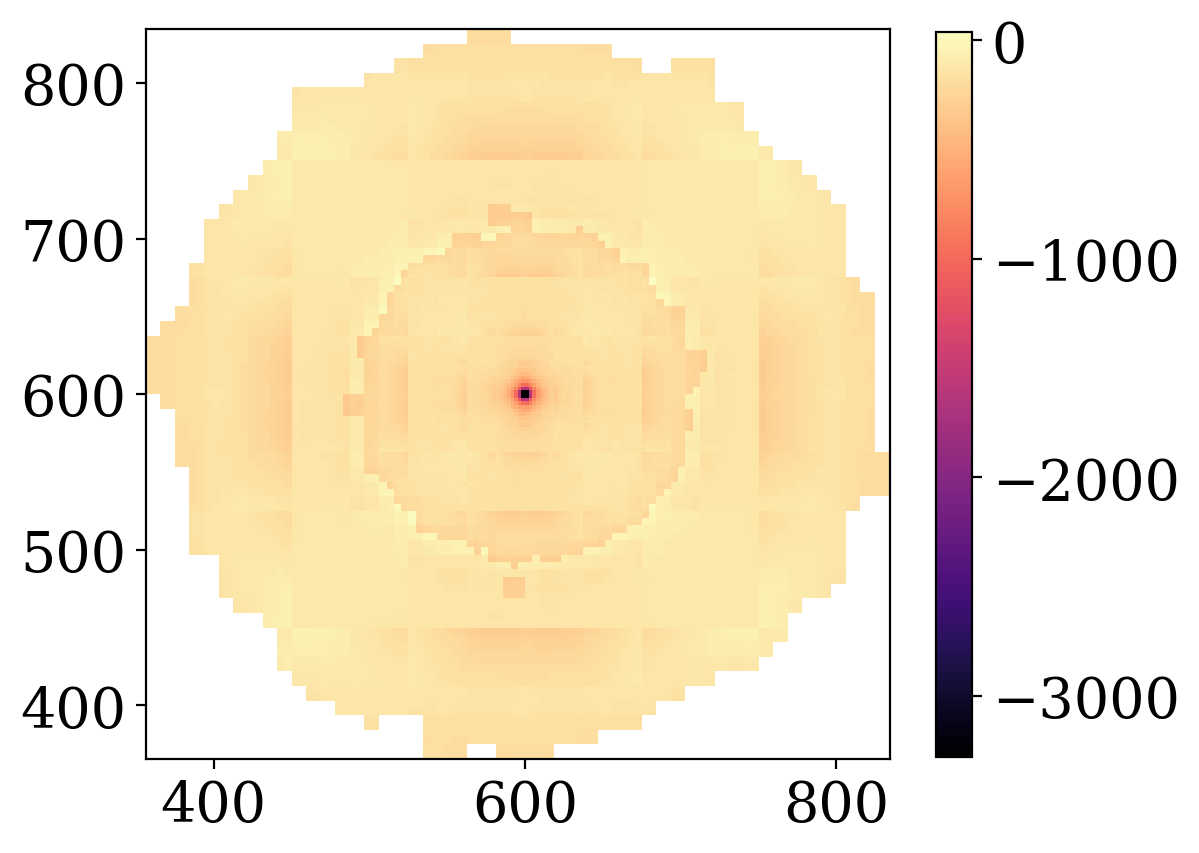

In [5]:
c = compare(24, 23, 600, False, [7,8])
plt.savefig("./fig/lev78.png")
#mk_image // project

Reading output 24 and base 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
image range: -3277.7578125 39.625
median relative error: 0.0037402271830726244


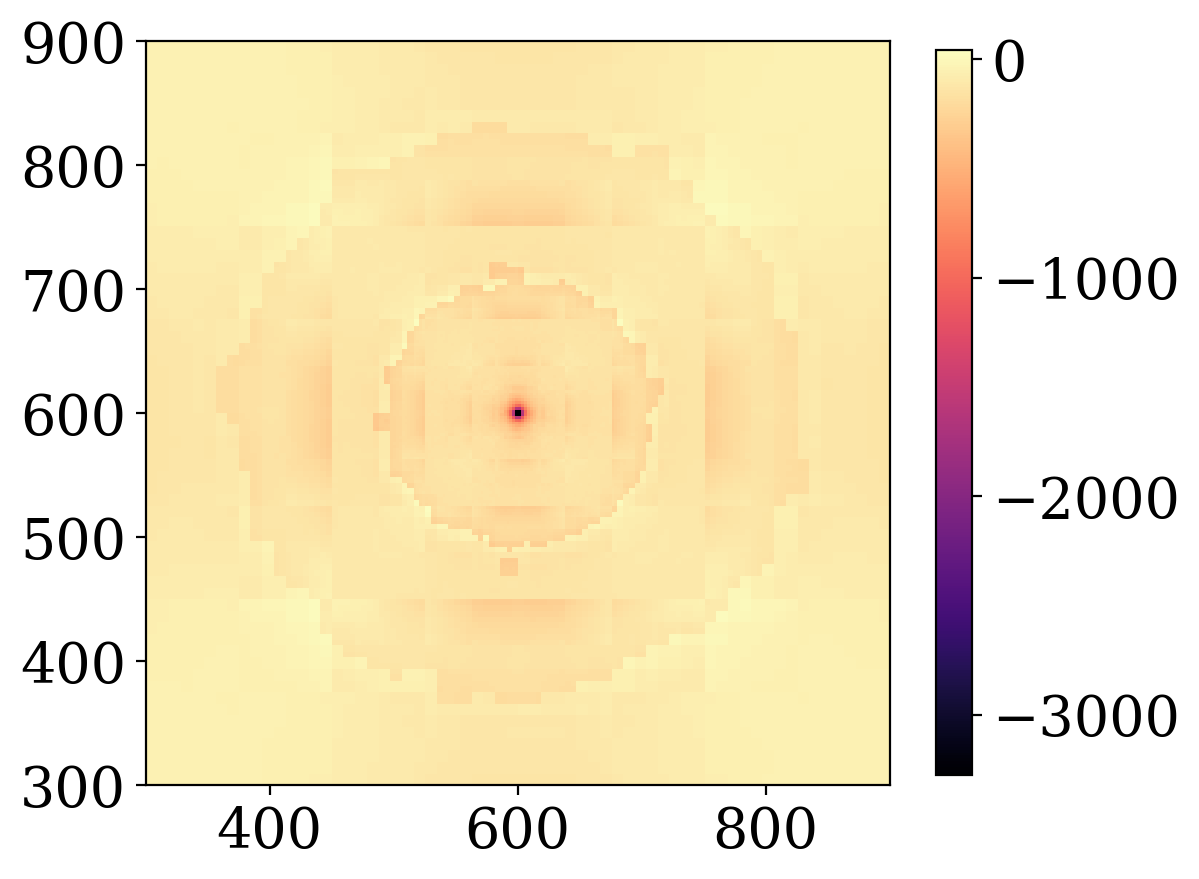

In [6]:
c = compare(24, 23, 600, False, [6,7,8])
plt.savefig("./fig/lev678.png")
#mk_image // project

Reading output 4 and base 3
ncpu=1 ndim=3 nlevelmax=8
Time= 0.00509681502068084
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 688283 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=8
Time= 0.00509681502068084
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 688283 leaf cells
Extracting leaf cells...
image range: -5314.3828125 26.111328125
median relative error: 0.0019731986328979014


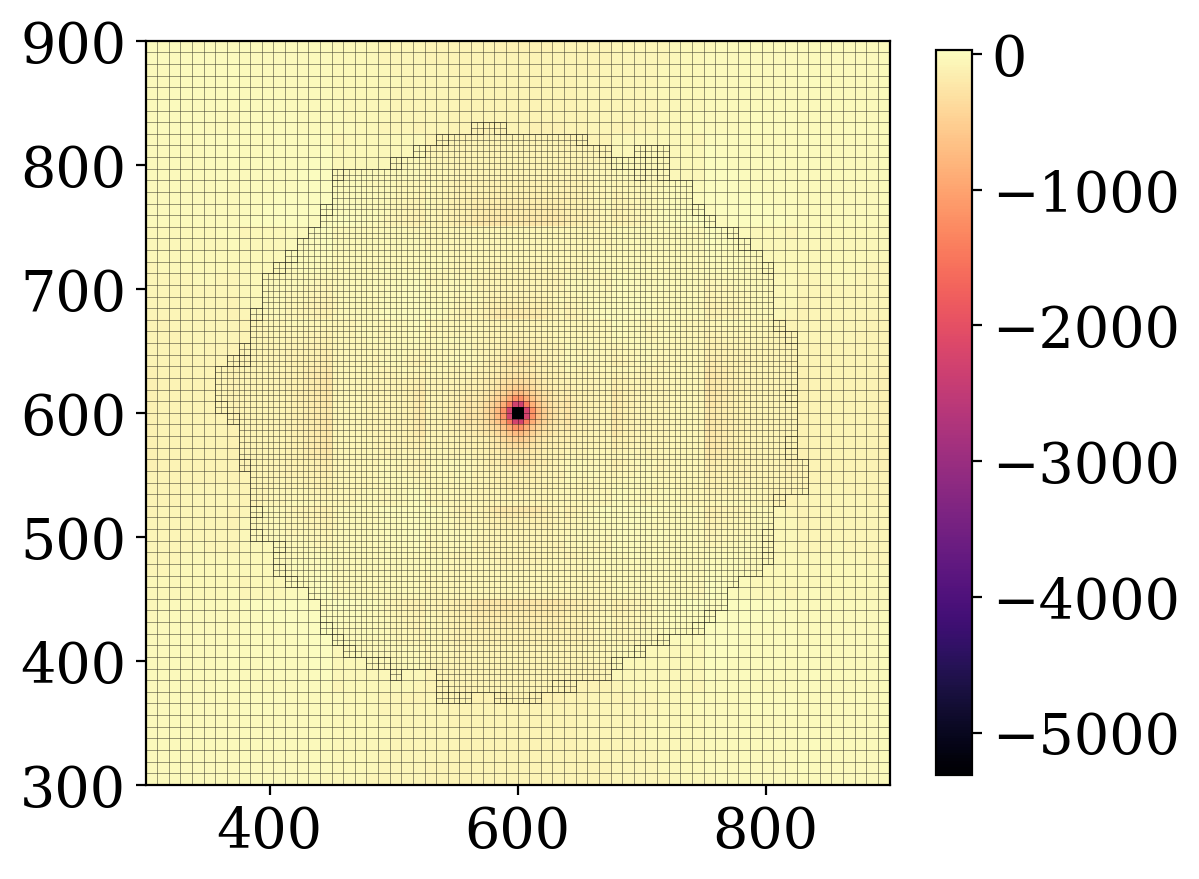

In [7]:
c = compare(4, 3, 600, True)
#mk_image // project

Reading output 2
ncpu=1 ndim=3 nlevelmax=10
Time= 0.00127420375517021
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1314643 leaf cells
Extracting leaf cells...
Available levels: [6 7 8 9]
image range: -539608704.0 535417920.0


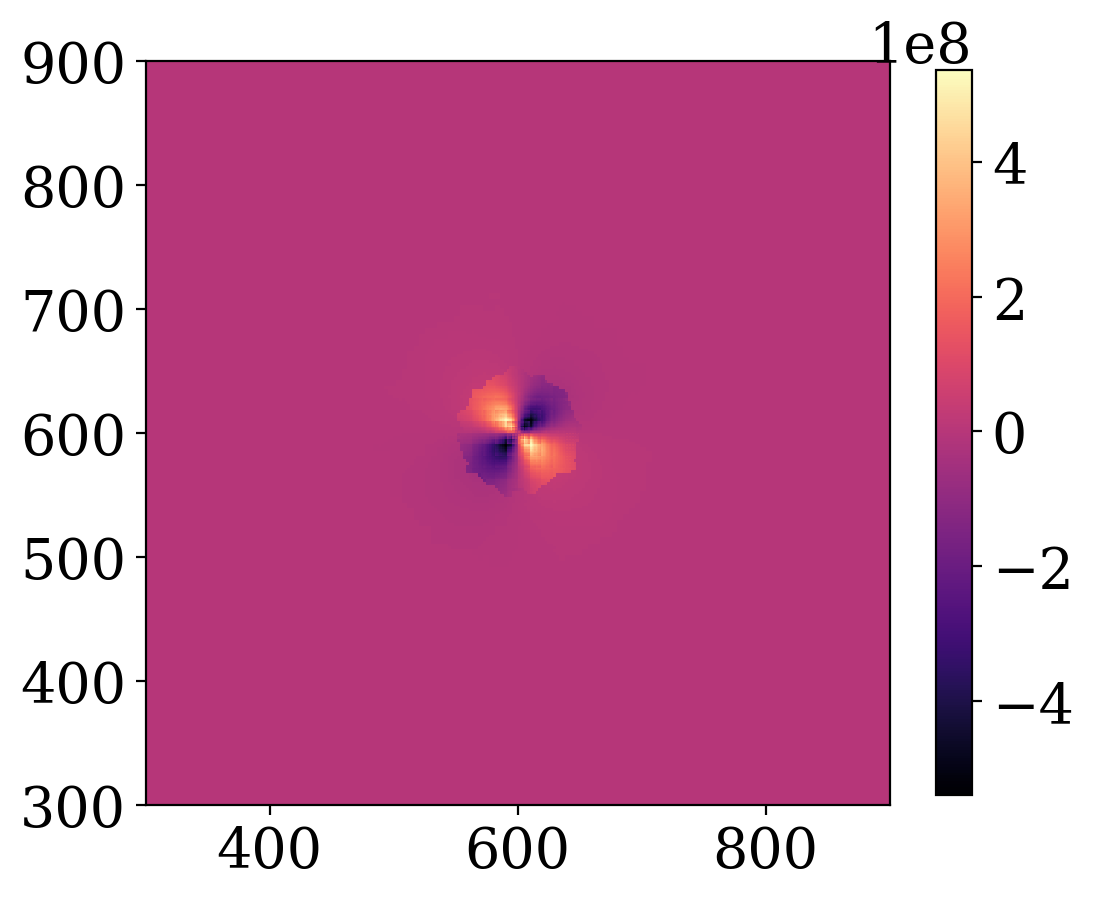

In [8]:
plot(2,600)

Reading output 5 and base 6
ncpu=1 ndim=3 nlevelmax=8
Time= 0.00509681502068084
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 2097152 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=8
Time= 0.00509681502068084
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 2097152 leaf cells
Extracting leaf cells...
image range: -5267.96875 71.765625
median relative error: 0.00045116422889687383


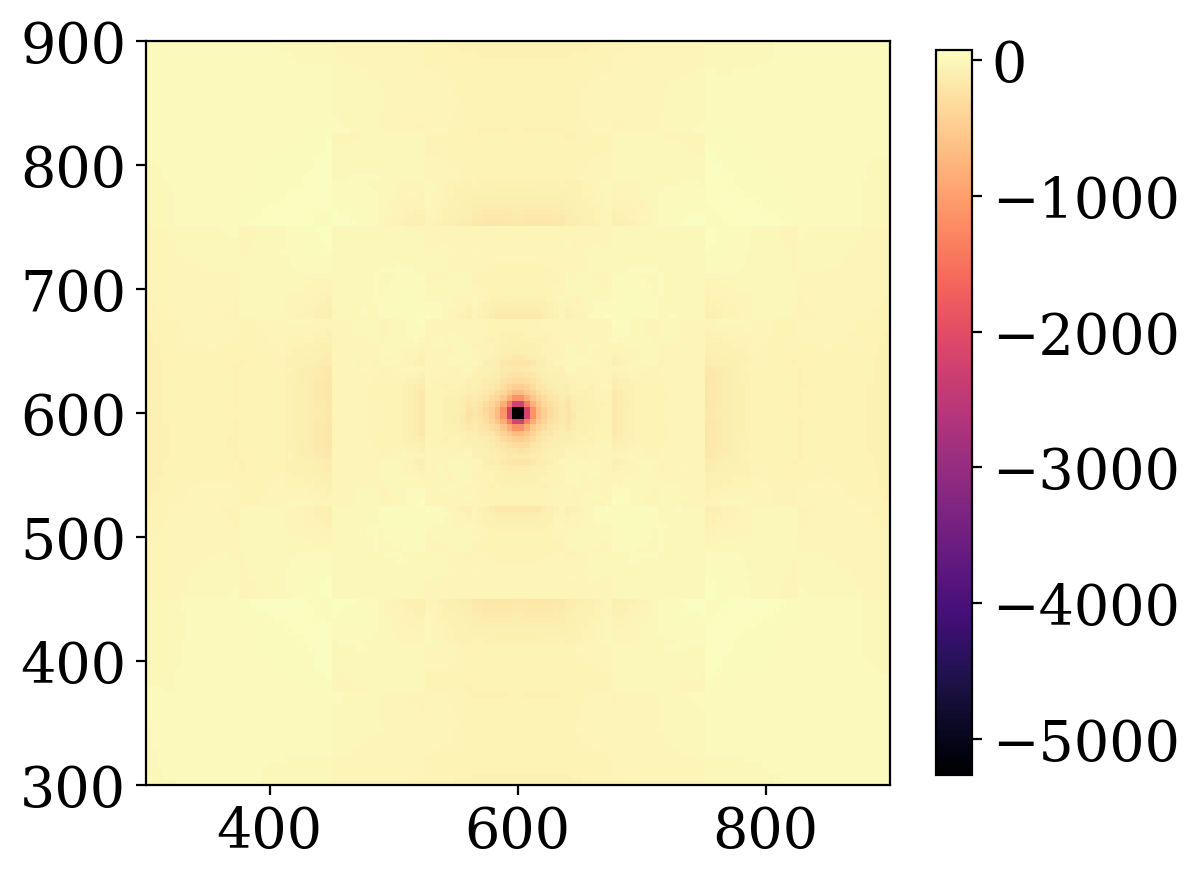

In [9]:
compare(5,6, 600, False)

Reading output 4 and base 3
ncpu=1 ndim=3 nlevelmax=8
Time= 0.00509681502068084
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 688283 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=8
Time= 0.00509681502068084
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 688283 leaf cells
Extracting leaf cells...
image range: -5314.3828125 26.111328125
median relative error: 0.0019731986328979014


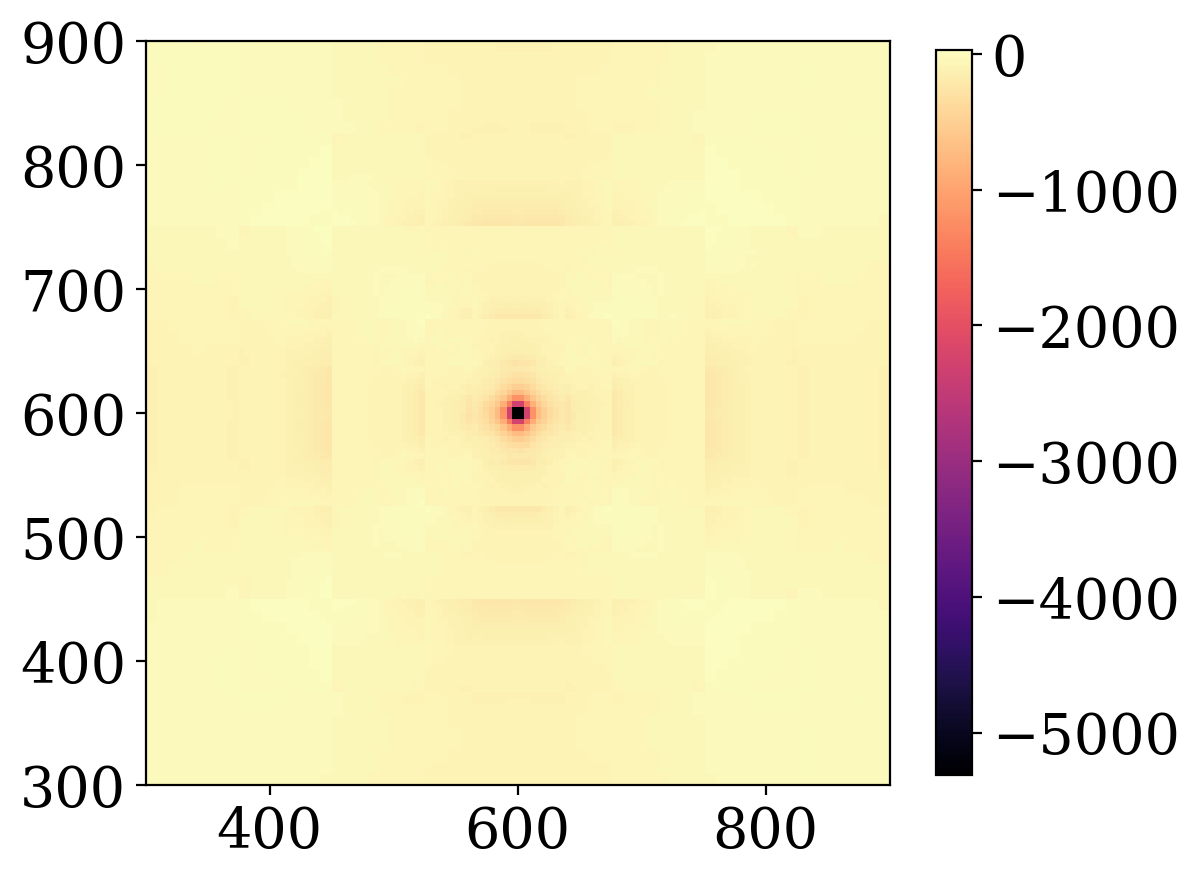

In [10]:
compare(4,3, 600, False)

Reading output 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
Available levels: [6 7 8]
image range: -130217.2109375 -37048.78125
Reading output 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
Available levels: [6 7 8]
image range: -44965.15234375 -22240.92578125
Reading output 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
Available levels: [6 7 8]
image range: -130217.2109375 -13209.1123046875


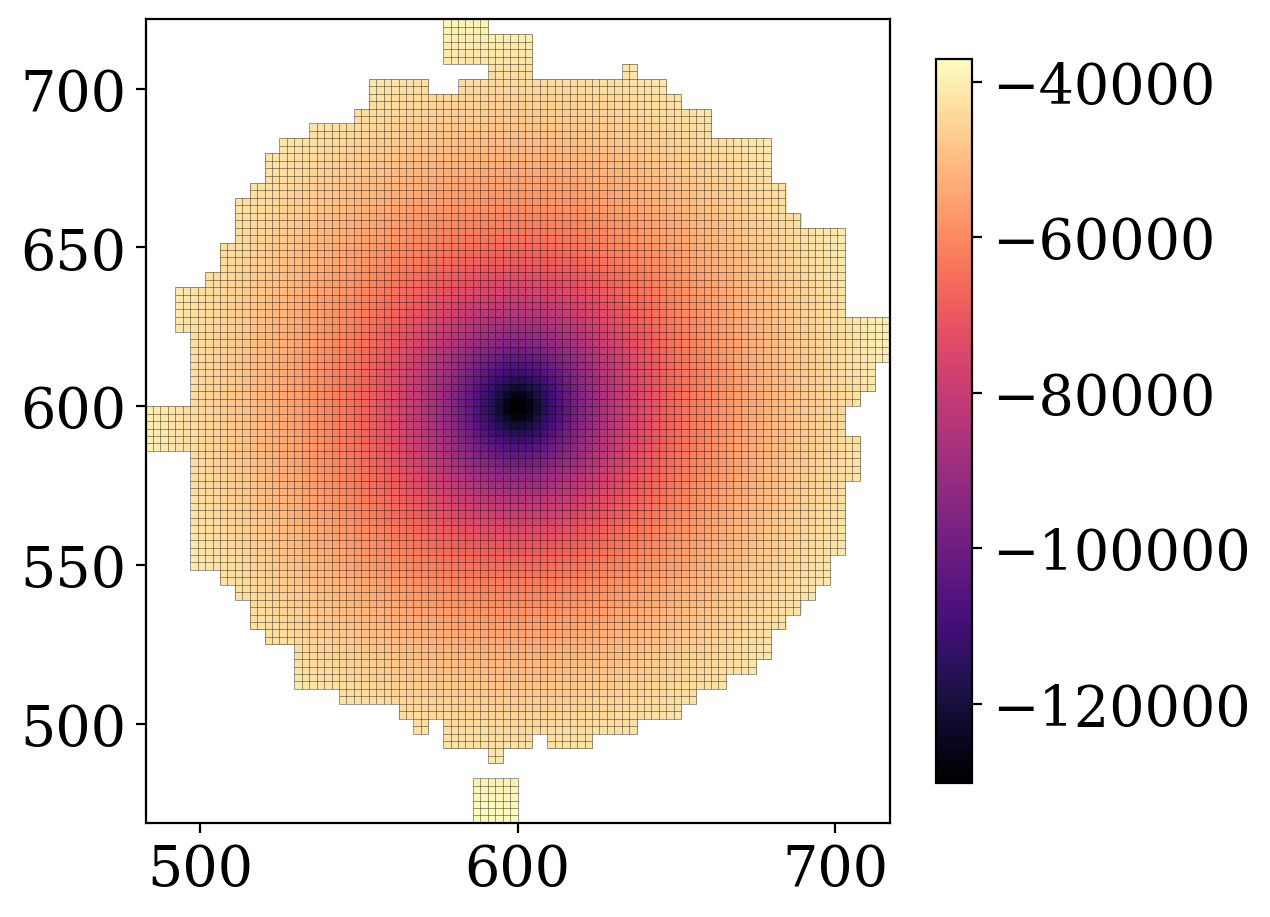

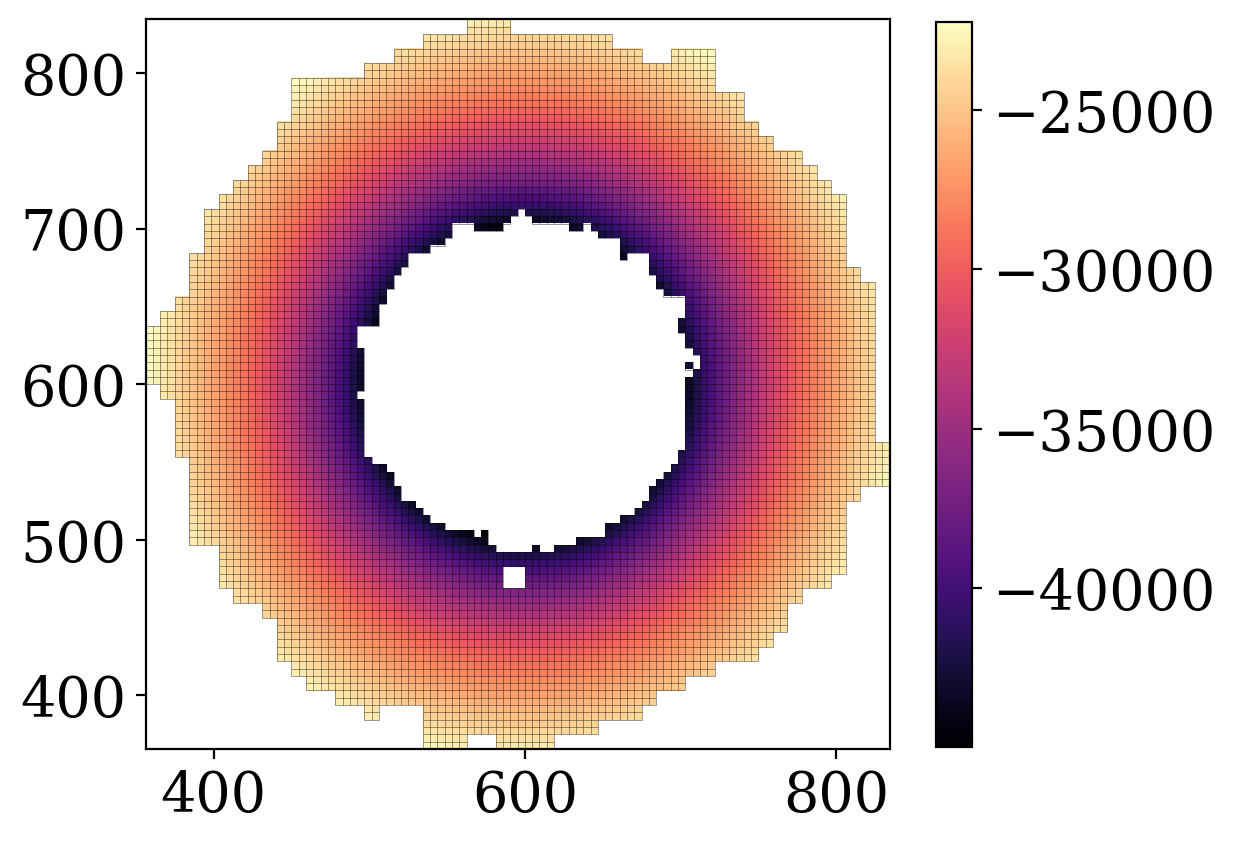

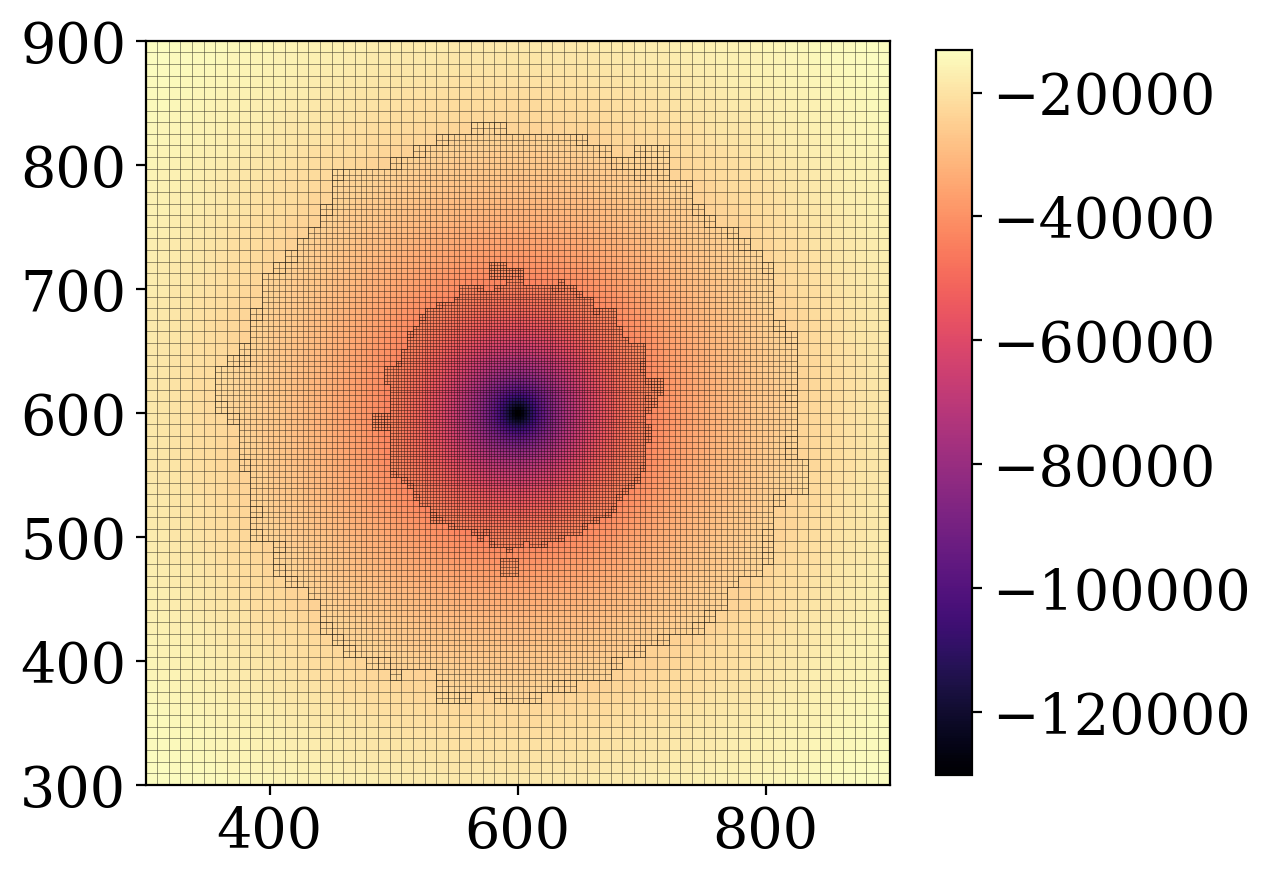

In [11]:
plot(23, 600, True, [8])
plot(23, 600, True, [7])
plot(23, 600, True, [6,7,8])

Reading output 2
ncpu=1 ndim=3 nlevelmax=10
Time= 0.00127420375517021
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1314643 leaf cells
Extracting leaf cells...
Available levels: [6 7 8 9]
image range: -539608704.0 535417920.0


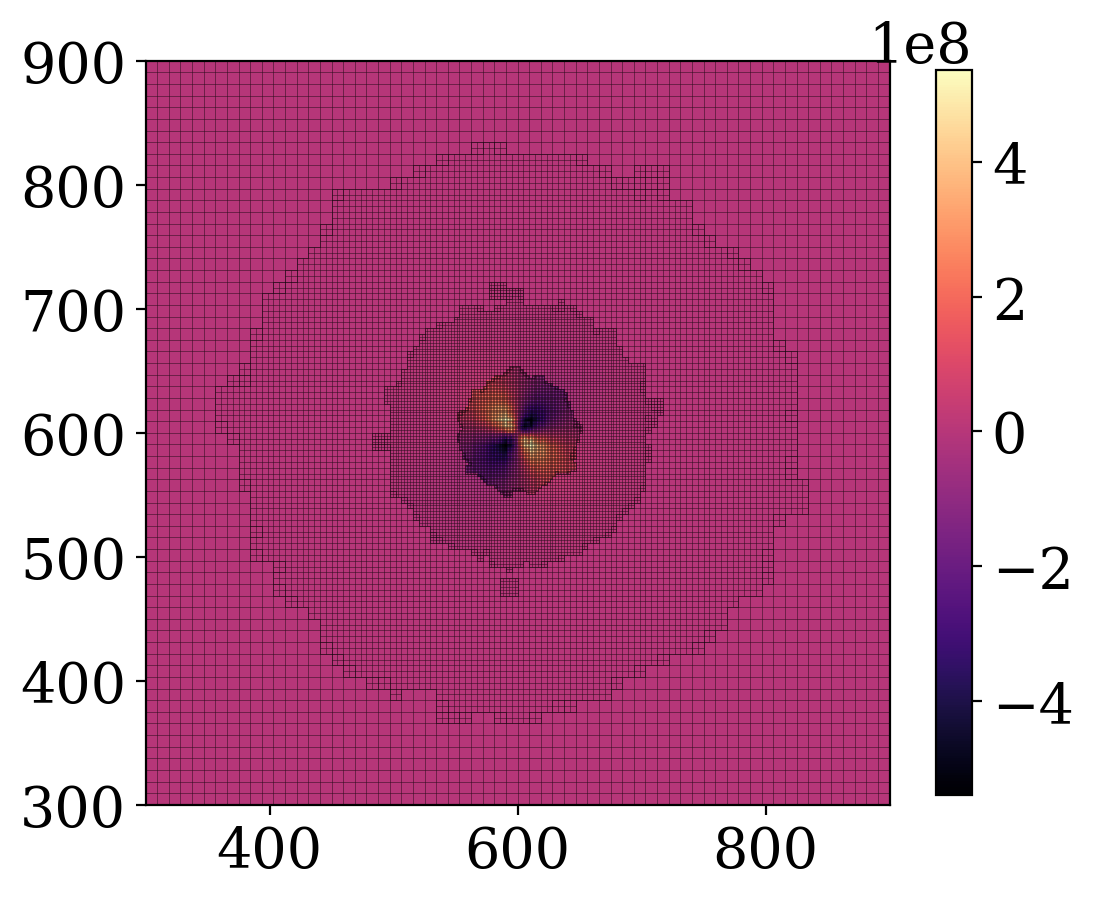

In [12]:
plot(2, 600, True)
plt.savefig('./fig/nfw_6789.png')

In [13]:
#mg
'''
     seconds         %    STEP
       0.127       1.0    refine                  
       2.844      21.4    rho                     
       7.502      56.4    poisson                 
       2.797      21.0    particle - kickdrift    
       0.030       0.2    time step               
      13.300     100.0    TOTAL
'''

'\n     seconds         %    STEP\n       0.127       1.0    refine                  \n       2.844      21.4    rho                     \n       7.502      56.4    poisson                 \n       2.797      21.0    particle - kickdrift    \n       0.030       0.2    time step               \n      13.300     100.0    TOTAL\n'

In [14]:
#fmm

'''
     seconds         %    STEP
       0.068       0.5    refine                  
       3.020      23.7    rho                     
       7.583      59.6    poisson                 
       0.108       0.9    grav force              
       1.896      14.9    particle - kickdrift    
       0.028       0.2    time step               
       0.017       0.1    recursive call          
      12.721     100.0    TOTAL
'''

'\n     seconds         %    STEP\n       0.068       0.5    refine                  \n       3.020      23.7    rho                     \n       7.583      59.6    poisson                 \n       0.108       0.9    grav force              \n       1.896      14.9    particle - kickdrift    \n       0.028       0.2    time step               \n       0.017       0.1    recursive call          \n      12.721     100.0    TOTAL\n'

Reading output 13
ncpu=1 ndim=3 nlevelmax=9
Time= 0.102467374407592
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 2097208 leaf cells
Extracting leaf cells...
Available levels: [7 8]
image range: -0.25971388816833496 -0.02511351928114891


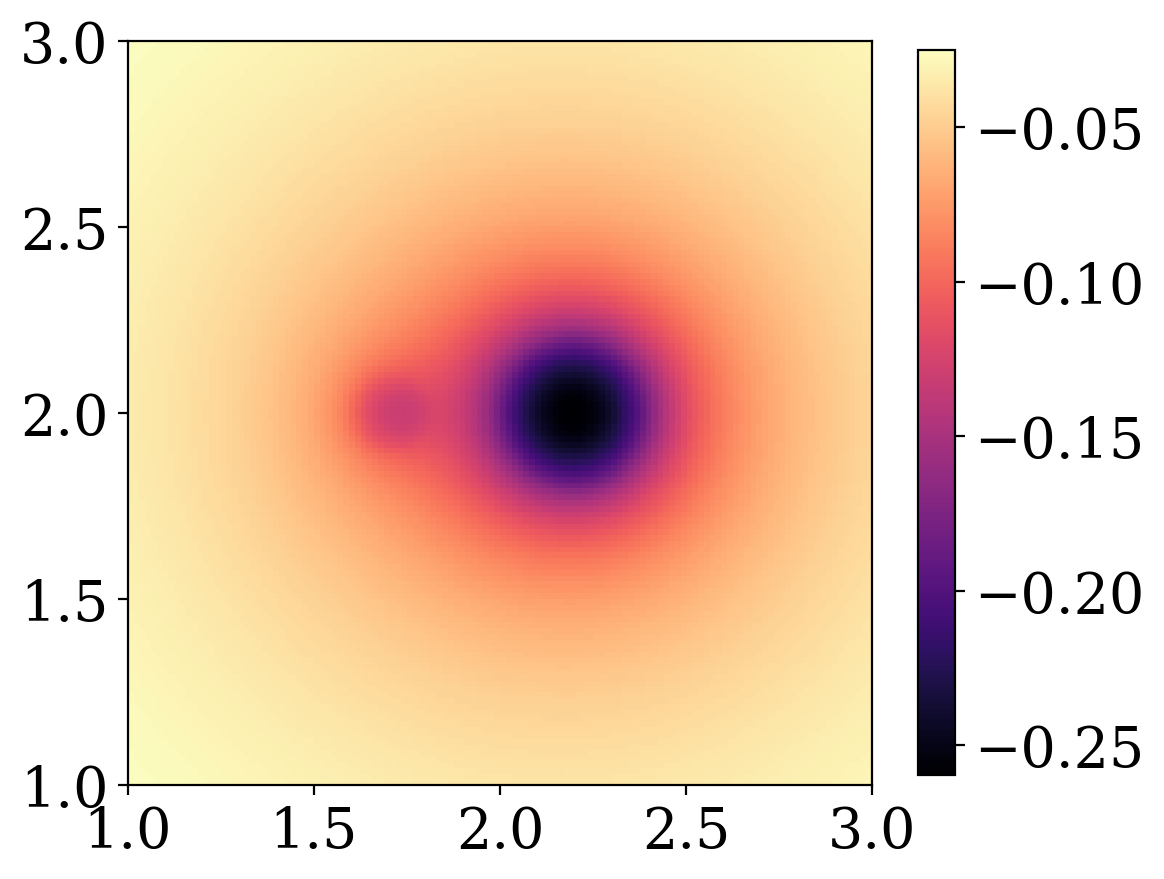

In [15]:
plot(13, 2, False)

Reading output 13 and base 14
ncpu=1 ndim=3 nlevelmax=9
Time= 0.102467374407592
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 2097208 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=9
Time= 0.103960080008642
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 2097208 leaf cells
Extracting leaf cells...
image range: -0.0009692981839179993 0.0006751567125320435
median relative error: 0.0008832229634223266


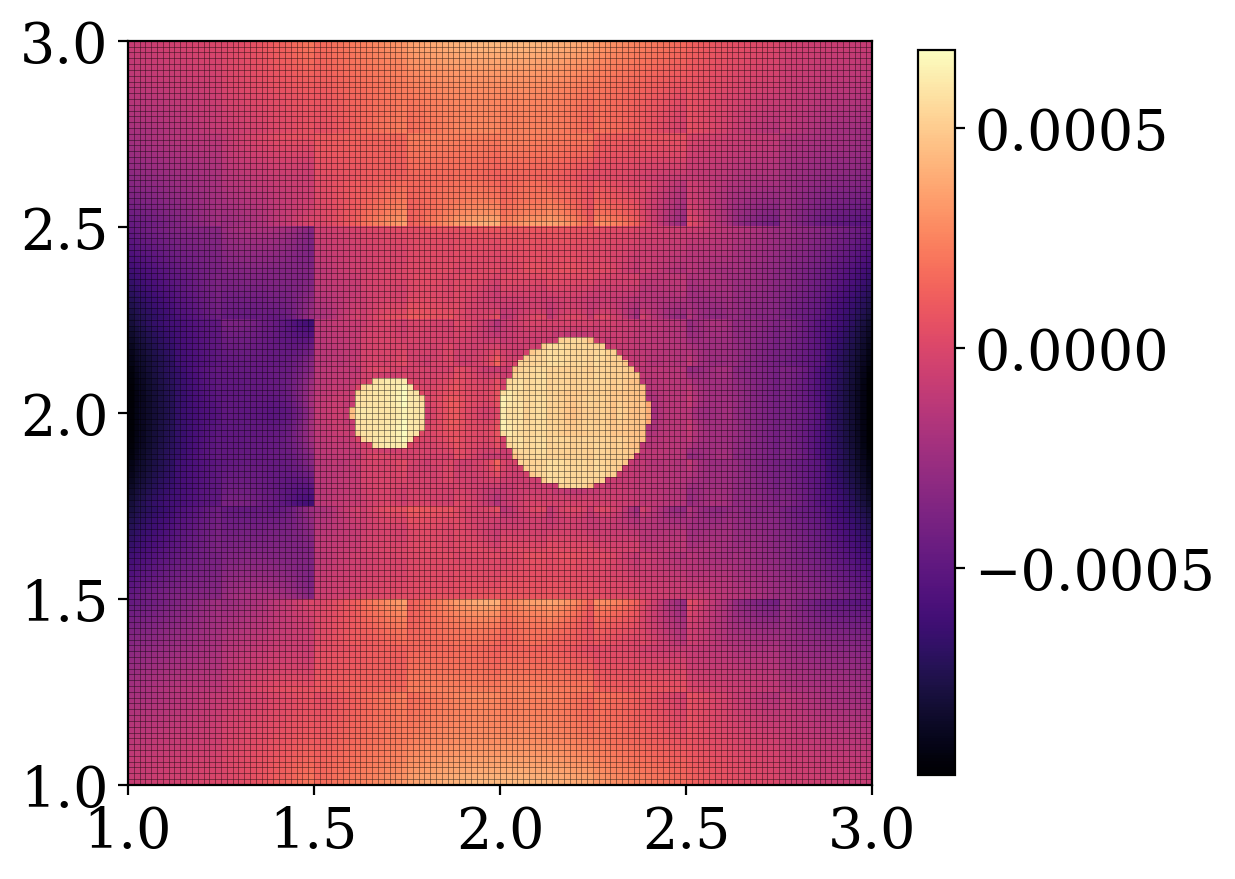

In [16]:
compare(13, 14, 2, True)

Reading output 2
ncpu=1 ndim=3 nlevelmax=10
Time= 0.00127420375517021
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1314643 leaf cells
Extracting leaf cells...
Available levels: [6 7 8 9]
image range: -539608704.0 535417920.0


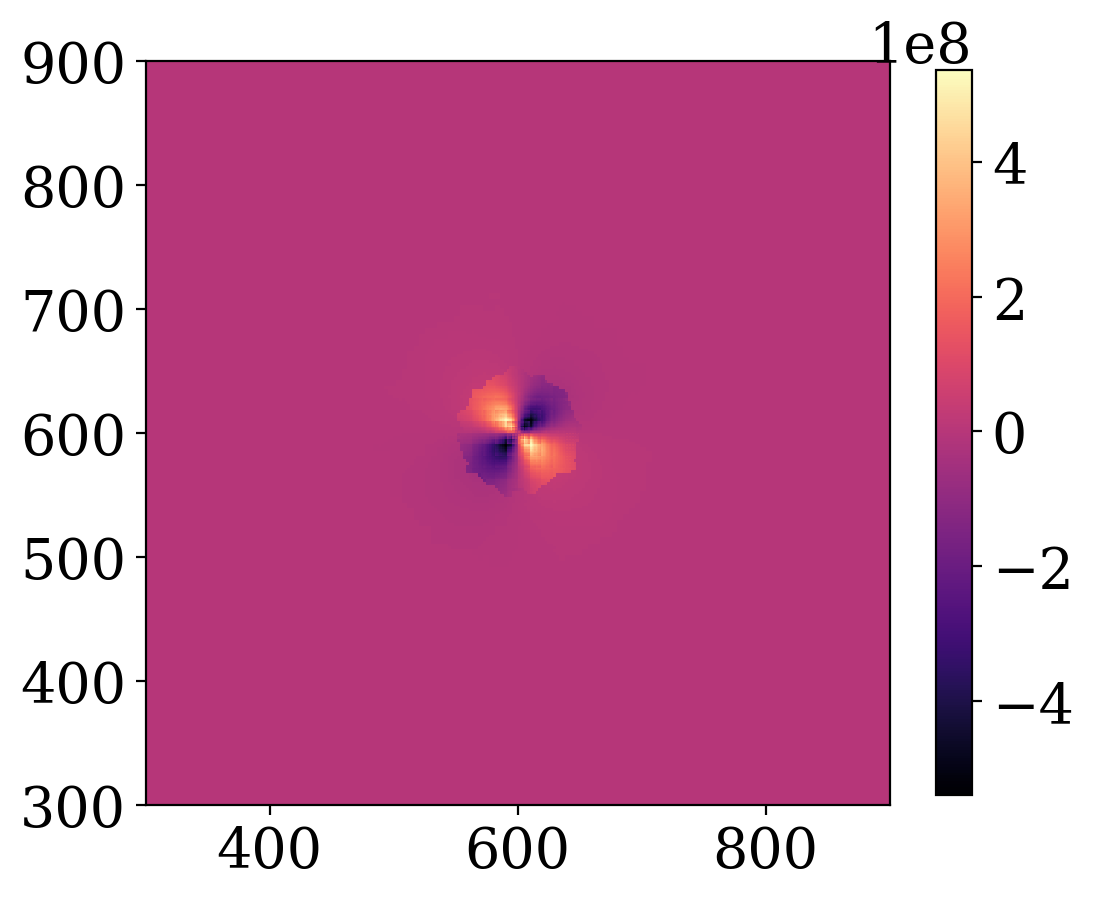

In [17]:
plot(2, 600, False)